# Random Inputation

## Import Libraries


In [1]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import  train_test_split
import warnings
warnings.filterwarnings('ignore')

## Import Dataset


In [2]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day38-missing-indicator/train.csv"

In [ ]:
df = pd.read_csv(url, usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


Check the null value in all features

In [4]:
df.isnull().mean()  *100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

Split the feature and target

In [5]:
X =df.drop(['Survived'], axis=1)
y = df['Survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Start the Imputatioin Process

In [7]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [8]:
X_train.head()

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0


There are `140` null values in `Age`.

In [9]:
X_train['Age'].isnull().sum()

np.int64(140)

## Handling Missing Values using Random Sampling

In this step, we are filling missing values in the `Age_imputed` column using random values from the existing (non-null) `Age` data.

### What the code does:

- First, it identifies the missing values (`NaN`) in the `Age_imputed` column.
- Then, it takes all the available (non-null) values from the original `Age` column.
- From these available values, it randomly samples the same number of values as the missing entries.
- Finally, it replaces the missing values in `Age_imputed` with these randomly selected values.

### Breakdown:

- `X_train['Age_imputed'].isnull()`
  → Finds rows where `Age_imputed` is missing.

- `X_train["Age"].dropna()`
  → Removes missing values and keeps only valid `Age` data.

- `.sample(X_train['Age'].isnull().sum())`
  → Randomly selects values equal to the number of missing entries.

- `.values`
  → Converts the sampled data into an array format for assignment.

- Same process is applied to `X_test`.

### Why this is useful:

- Preserves the original distribution of the `Age` feature.
- Better than mean/median imputation in some cases.
- Adds randomness, which can help improve model generalization.


In [10]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train["Age"].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test["Age"].dropna().sample(X_test['Age'].isnull().sum()).values

In [11]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,16.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


Now we see that the distribution of the `Age` and `Age_imputed` column so there is very little change.

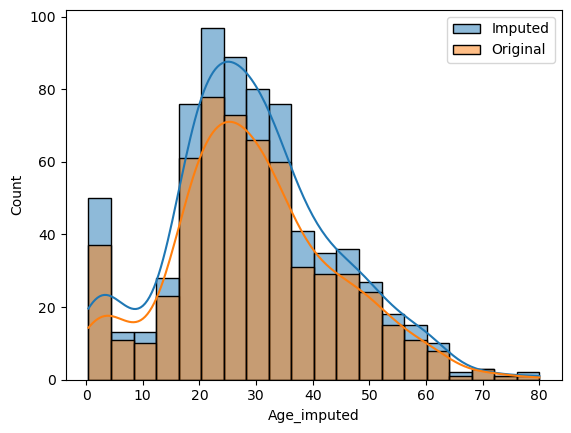

In [12]:
sns.histplot(X_train['Age_imputed'], label= "Imputed", kde=True)
sns.histplot(X_train['Age'], label= "Original",kde=True)

plt.legend()
plt.show()

variance doesnt change too much so its just right.

In [13]:
print("Original varibale variance : ", X_train['Age'].var())
print("Imputed varibale variance : ", X_train['Age_imputed'].var())

Original varibale variance :  210.2517072477438
Imputed varibale variance :  215.19759457146122


Yeah, there are something the covariance of the features are change that effect on the models.

In [14]:
X_train[['Fare','Age_imputed',"Age"]].cov()

,Fare,Age_imputed,Age
Fare,2700.831981,52.170495,71.580633
Age_imputed,52.170495,215.197595,210.251707
Age,71.580633,210.251707,210.251707


Outliers not effected by the Imputation

<Axes: >

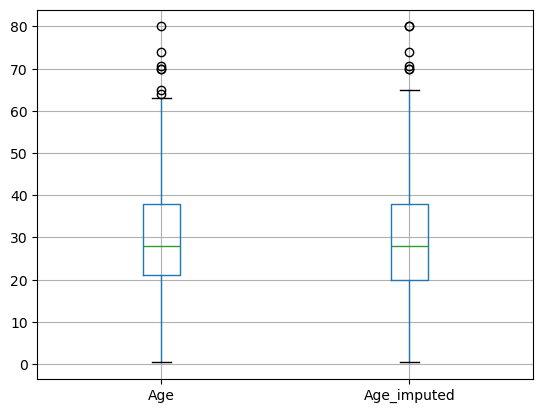

In [15]:
X_train[["Age","Age_imputed"]].boxplot()

## Change the Dataset for Categorical Values

In [16]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [17]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [18]:
data.isnull().mean() *100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [19]:
X = data
y = data['SalePrice']

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']


In [22]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
388,NaN,TA,191000,TA,NaN
820,NaN,TA,183000,TA,NaN
963,NaN,TA,239000,TA,NaN
238,NaN,TA,318000,TA,NaN
443,Gd,TA,172500,TA,Gd


In [23]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

Check the ratio of the value after and before the imputation

In [24]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [25]:
temp

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.001712
Ex,0.000907,0.000856


In [26]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.652076
TA,0.412439,0.536476
Fa,0.040917,0.052750
Po,0.027823,0.035915
Ex,0.024550,0.033670


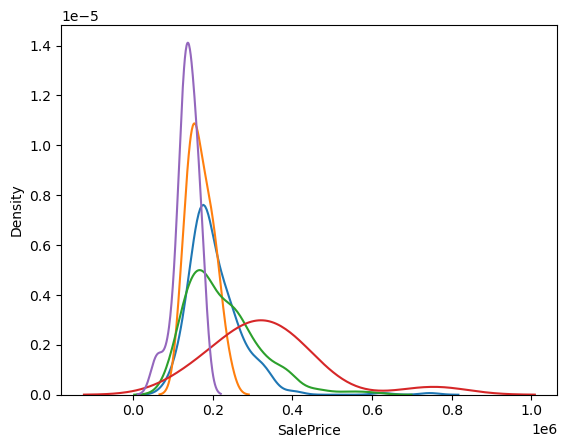

In [27]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

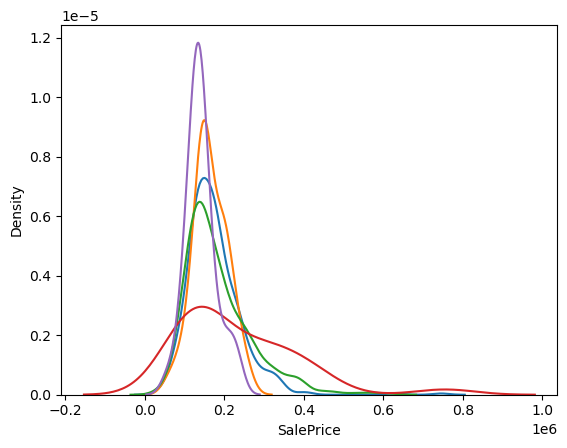

In [28]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()

**Observation : There are so many changes in the the columns after the imputation.**